In [ ]:
# ==============================================================================
# 1. SETUP: MOUNT DRIVE, IMPORT LIBRARIES, LOAD PROCESSED DATA
# ==============================================================================
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# For Autoencoder (using TensorFlow/Keras)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# For Incremental XGBoost
import xgboost as xgb

print("All modeling libraries imported.")

# --- Define your output path (where you saved the files) ---
output_path = "/content/drive/MyDrive/Colab_Datasets/PreprocessedForproject"

# --- Load the saved files ---
parquet_file = os.path.join(output_path, 'cicids2017_processed.parquet')
encoder_file = os.path.join(output_path, 'label_encoder.pkl')
scaler_file = os.path.join(output_path, 'scaler.pkl')

print("Loading processed files from Google Drive...")
try:
    processed_data = pd.read_parquet(parquet_file)
    with open(encoder_file, 'rb') as f:
        label_encoder = pickle.load(f)
    with open(scaler_file, 'rb') as f:
        scaler = pickle.load(f)
    print("\nProcessed data and saved objects loaded successfully.")
    print(f"Data shape: {processed_data.shape}")
except FileNotFoundError:
    print(f"!!! ERROR: Could not find processed files in '{output_path}'.")
    print("Please ensure the path is correct and the preprocessing notebook was run successfully.")
    # Stop execution if files aren't found
    exit()

Mounted at /content/drive
All modeling libraries imported.
Loading processed files from Google Drive...

Processed data and saved objects loaded successfully.
Data shape: (2520762, 56)


In [ ]:
# ==============================================================================
# 2. PREPARE DATA SPLIT
# ==============================================================================

# --- Separate Features and Target ---
X = processed_data.drop(columns=['Attack Type'])
y = processed_data['Attack Type']

# --- Get Numerical Label for Benign ---
benign_label_numeric = label_encoder.transform(['Benign'])[0]
print(f"Numerical label for 'Benign': {benign_label_numeric}")

# --- Split Data into Training and Testing Sets ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nData split into training and testing sets:")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape},  y_test shape: {y_test.shape}")

Numerical label for 'Benign': 0

Data split into training and testing sets:
X_train shape: (2016609, 55), y_train shape: (2016609,)
X_test shape: (504153, 55),  y_test shape: (504153,)


In [ ]:
# ==============================================================================
# 3. PREPARE DATA FOR AUTOENCODER (Train only on Benign data)
# ==============================================================================

# Filter the training data for 'Benign' samples
X_train_benign = X_train[y_train == benign_label_numeric]
# Filter test data for 'Benign' samples (for validation during AE training)
X_test_benign = X_test[y_test == benign_label_numeric]

# Convert relevant dataframes/series to NumPy arrays for ML libraries
X_train_benign_np = X_train_benign.values
X_test_benign_np = X_test_benign.values
X_train_np = X_train.values
X_test_np = X_test.values
y_train_np = y_train.values
y_test_np = y_test.values

print(f"Benign data prepared for Autoencoder training:")
print(f"X_train_benign_np shape: {X_train_benign_np.shape}")
print(f"X_test_benign_np shape: {X_test_benign_np.shape}")

Benign data prepared for Autoencoder training:
X_train_benign_np shape: (1676045, 55)
X_test_benign_np shape: (419012, 55)


Defining and training the Autoencoder...
Epoch 1/100
6548/6548 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - loss: 0.3446 - val_loss: 0.3163
Epoch 2/100
6548/6548 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.3152 - val_loss: 0.3151
Epoch 3/100
6548/6548 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.3146 - val_loss: 0.3144
Epoch 4/100
6548/6548 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 0.3137 - val_loss: 0.3140
Epoch 5/100
6548/6548 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.3135 - val_loss: 0.3139
Epoch 6/100
6548/6548 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 0.3130 - val_loss: 0.3135
Epoch 7/100
6548/6548 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.3132 - val_loss: 0.3134
Epoch 8/100
6548/6548 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 0.3127 - val_loss: 0.3133
Epoch 9/100
6548/6548 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.3129 - val_loss: 0.3132
Epoch 10/100
6548/6548 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 0.3131 - val_loss: 0.3132
Epoch 11/100
6548/6548 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step -


Autoencoder training complete.
Encoder model saved to: /content/drive/MyDrive/Colab_Datasets/PreprocessedForproject/encoder_model.h5


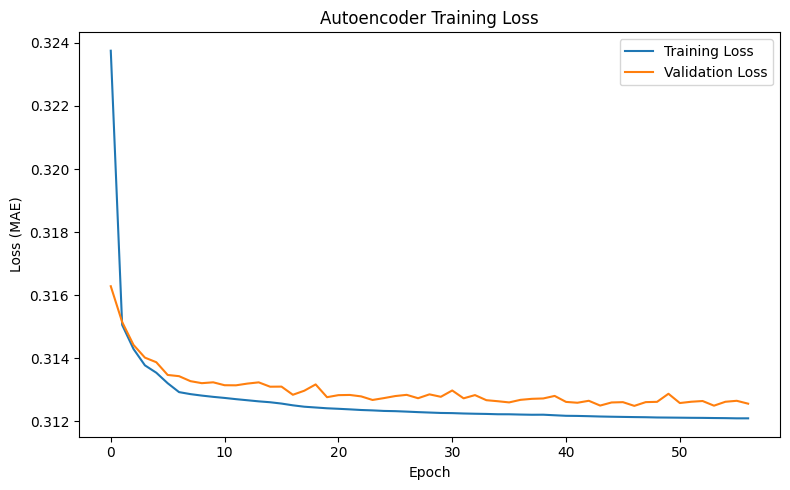

In [ ]:
# ==============================================================================
# 4. DEFINE AND TRAIN THE AUTOENCODER MODEL
# ==============================================================================

print("Defining and training the Autoencoder...")

# --- Define Autoencoder Architecture ---
input_dim = X_train_benign_np.shape[1]
encoding_dim = 32 # Bottleneck size (you can tune this)

input_layer = keras.Input(shape=(input_dim,))
# Encoder
encoded = layers.Dense(input_dim // 2, activation='relu')(input_layer)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)
# Decoder
decoded = layers.Dense(input_dim // 2, activation='relu')(encoded)
decoded = layers.Dense(input_dim, activation='sigmoid')(decoded)

# Autoencoder Model (Input -> Reconstruction)
autoencoder = Model(input_layer, decoded)
# Separate Encoder Model (Input -> Encoded Representation)
encoder_model = Model(input_layer, encoded)

# Compile
autoencoder.compile(optimizer='adam', loss='mae')

# --- Train ---
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = autoencoder.fit(
    X_train_benign_np,
    X_train_benign_np,
    epochs=100,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test_benign_np, X_test_benign_np),
    callbacks=[early_stopping],
    verbose=1
)
print("\nAutoencoder training complete.")

# --- Save the Encoder Model ---
encoder_model_path = os.path.join(output_path, 'encoder_model.h5')
encoder_model.save(encoder_model_path)
print(f"Encoder model saved to: {encoder_model_path}")

# --- Plot Loss ---
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'autoencoder_loss.png'), dpi=300)
plt.show()

--- Executing Minor Project Logic (Anomaly Detection) ---
Calculating reconstruction error on Benign samples...
Anomaly Threshold set to: 0.808848
Reconstructing full test set...

--- Minor Project Results ---
Accuracy: 84.50%

Classification Report (0=Normal, 1=Attack):
              precision    recall  f1-score   support

      Normal       0.86      0.98      0.91    419012
      Attack       0.63      0.20      0.31     85141

    accuracy                           0.85    504153
   macro avg       0.74      0.59      0.61    504153
weighted avg       0.82      0.85      0.81    504153

--- Generating Visualizations ---


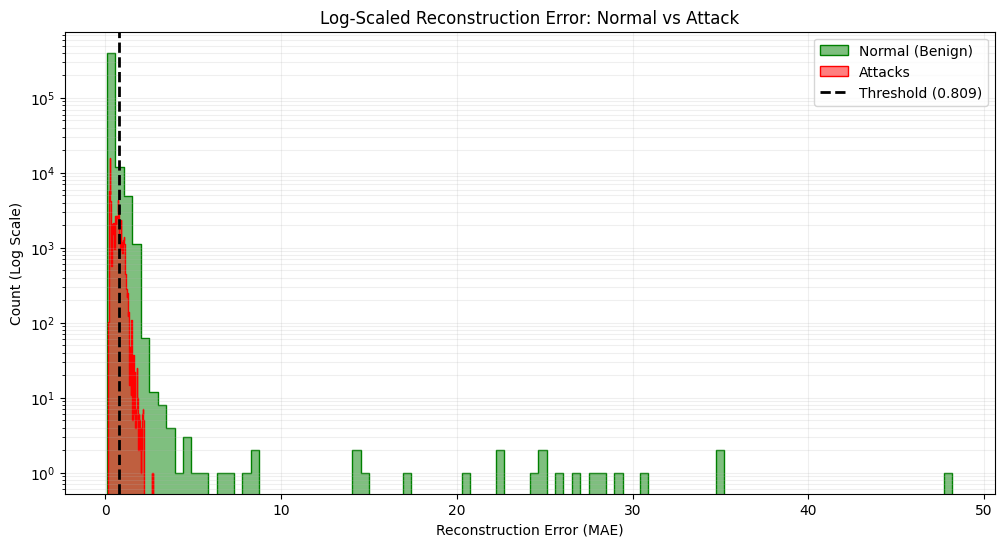

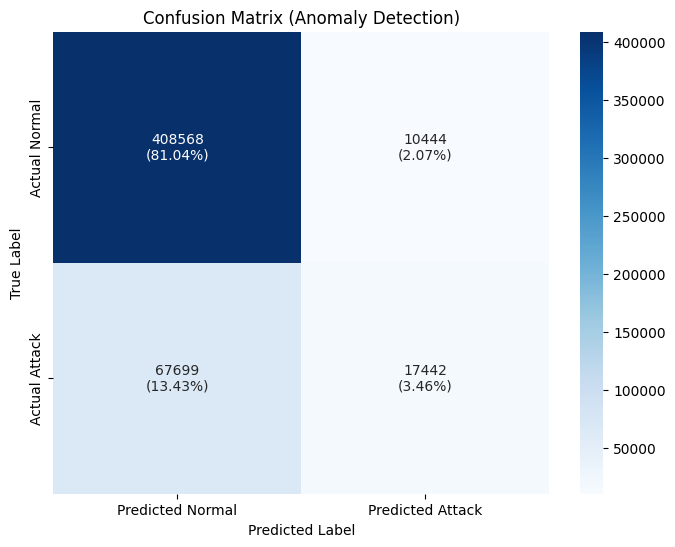

In [ ]:
# ==============================================================================
# STEP 4-B: MINOR PROJECT IMPLEMENTATION (Anomaly Based IDS)
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("--- Executing Minor Project Logic (Anomaly Detection) ---")

# --- 1. LOGIC & CALCULATIONS ---

# A. Determine Threshold using Benign Data
print("Calculating reconstruction error on Benign samples...")
# (X_test_benign_np and autoencoder must be loaded from previous steps)
benign_reconstructions = autoencoder.predict(X_test_benign_np, verbose=0)
benign_mae = np.mean(np.abs(benign_reconstructions - X_test_benign_np), axis=1)

# Set Threshold: Mean + 2 Standard Deviations
threshold = np.mean(benign_mae) + 2 * np.std(benign_mae)
print(f"Anomaly Threshold set to: {threshold:.6f}")

# B. Detect Anomalies on the Full Test Set
print("Reconstructing full test set...")
test_reconstructions = autoencoder.predict(X_test_np, verbose=0)
test_mae = np.mean(np.abs(test_reconstructions - X_test_np), axis=1)

# C. Make Predictions
# Error > Threshold = Attack (1), Error <= Threshold = Normal (0)
y_pred_anomaly = (test_mae > threshold).astype(int)

# D. Prepare Ground Truth (Convert to Binary)
# (benign_label_numeric must be defined from Step 2)
y_test_binary = (y_test_np != benign_label_numeric).astype(int)

# E. Evaluation Metrics
print("\n--- Minor Project Results ---")
acc = accuracy_score(y_test_binary, y_pred_anomaly)
print(f"Accuracy: {acc * 100:.2f}%")

print("\nClassification Report (0=Normal, 1=Attack):")
print(classification_report(y_test_binary, y_pred_anomaly, target_names=['Normal', 'Attack']))

# --- 2. IMPROVED VISUALIZATION ---
print("--- Generating Visualizations ---")

# Plot 1: Reconstruction Error Histogram (Log Scale)
plt.figure(figsize=(12, 6))
# Use Log Scale to make small Attack bars visible next to huge Normal bars
sns.histplot(benign_mae, bins=100, color='green', alpha=0.5, label='Normal (Benign)', element="step")
sns.histplot(test_mae[y_test_binary == 1], bins=100, color='red', alpha=0.5, label='Attacks', element="step")
plt.axvline(threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.3f})')

plt.yscale('log')  # <--- The Key Fix for visualization
plt.title("Log-Scaled Reconstruction Error: Normal vs Attack")
plt.xlabel("Reconstruction Error (MAE)")
plt.ylabel("Count (Log Scale)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

# Plot 2: Confusion Matrix with Percentages
cm = confusion_matrix(y_test_binary, y_pred_anomaly)

# Prepare labels with counts and percentages
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n({v2})" for v1, v2 in zip(group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Attack'],
            yticklabels=['Actual Normal', 'Actual Attack'])
plt.title('Confusion Matrix (Anomaly Detection)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# CELL 5-B: LOAD PRE-TRAINED ENCODER
print("Loading pre-trained Encoder model from Google Drive...")
encoder_model_path = os.path.join(output_path, 'encoder_model.h5')
encoder_model = keras.models.load_model(encoder_model_path)
print("Encoder model loaded successfully.")

Loading pre-trained Encoder model from Google Drive...


Encoder model loaded successfully.


In [ ]:
# ==============================================================================
# 5. TRANSFORM FULL DATA USING THE TRAINED ENCODER
# ==============================================================================
print("Transforming full training and testing data using the encoder...")

X_train_encoded = encoder_model.predict(X_train_np)
X_test_encoded = encoder_model.predict(X_test_np)

print("Data transformation complete.")
print(f"Encoded X_train shape: {X_train_encoded.shape}")
print(f"Encoded X_test shape: {X_test_encoded.shape}")

Transforming full training and testing data using the encoder...
63020/63020 ━━━━━━━━━━━━━━━━━━━━ 79s 1ms/step
15755/15755 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step
Data transformation complete.
Encoded X_train shape: (2016609, 32)
Encoded X_test shape: (504153, 32)


In [ ]:
# ==============================================================================
# 6. DEFINE AND TRAIN INITIAL XGBOOST MODEL (with tuning parameters)
# ==============================================================================
print("Training the initial XGBoost model...")

num_classes = len(label_encoder.classes_)
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=num_classes,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    tree_method='hist', # Use 'hist' (efficient CPU) to avoid GPU errors

    # Tuning Parameters
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8
)

print("XGBoost Classifier initialized. Starting training...")
xgb_model.fit(X_train_encoded, y_train_np)
print("Initial XGBoost model training complete.")

# --- Save the initial model ---
initial_model_path = os.path.join(output_path, 'initial_xgb_model_tuned.json')
xgb_model.save_model(initial_model_path)
print(f"Initial (tuned) XGBoost model saved to: {initial_model_path}")

Training the initial XGBoost model...
XGBoost Classifier initialized. Starting training...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:40:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Initial XGBoost model training complete.
Initial (tuned) XGBoost model saved to: /content/drive/MyDrive/Colab_Datasets/PreprocessedForproject/initial_xgb_model_tuned.json


In [ ]:
# CELL 7-B: LOAD PRE-TRAINED XGBOOST MODEL
print("Loading pre-trained XGBoost model from Google Drive...")
initial_model_path = os.path.join(output_path, 'initial_xgb_model_tuned.json')

# Re-define num_classes (needed for the next step)
num_classes = len(label_encoder.classes_)
print(f"num_classes set to {num_classes}")

# Initialize the model object with the SAME parameters as Cell 7
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=num_classes,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    tree_method='hist', # Make sure this matches!
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_model.load_model(initial_model_path) # Load the trained state
print("Initial XGBoost model loaded successfully.")

Loading pre-trained XGBoost model from Google Drive...
num_classes set to 8
Initial XGBoost model loaded successfully.


Evaluating the initial XGBoost model on the test set...

Accuracy on the test set: 99.77%

Using target names for report: ['Benign', 'Botnet', 'Brute Force', 'DDoS', 'DoS', 'PortScan', 'Web Attack', 'nan']

Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    419012
      Botnet       0.94      0.56      0.70       389
 Brute Force       0.99      0.98      0.98      1830
        DDoS       1.00      1.00      1.00     25603
         DoS       1.00      0.99      1.00     38749
    PortScan       0.98      0.99      0.99     18139
  Web Attack       1.00      1.00      1.00         2
         nan       0.97      0.95      0.96       429

    accuracy                           1.00    504153
   macro avg       0.98      0.93      0.95    504153
weighted avg       1.00      1.00      1.00    504153



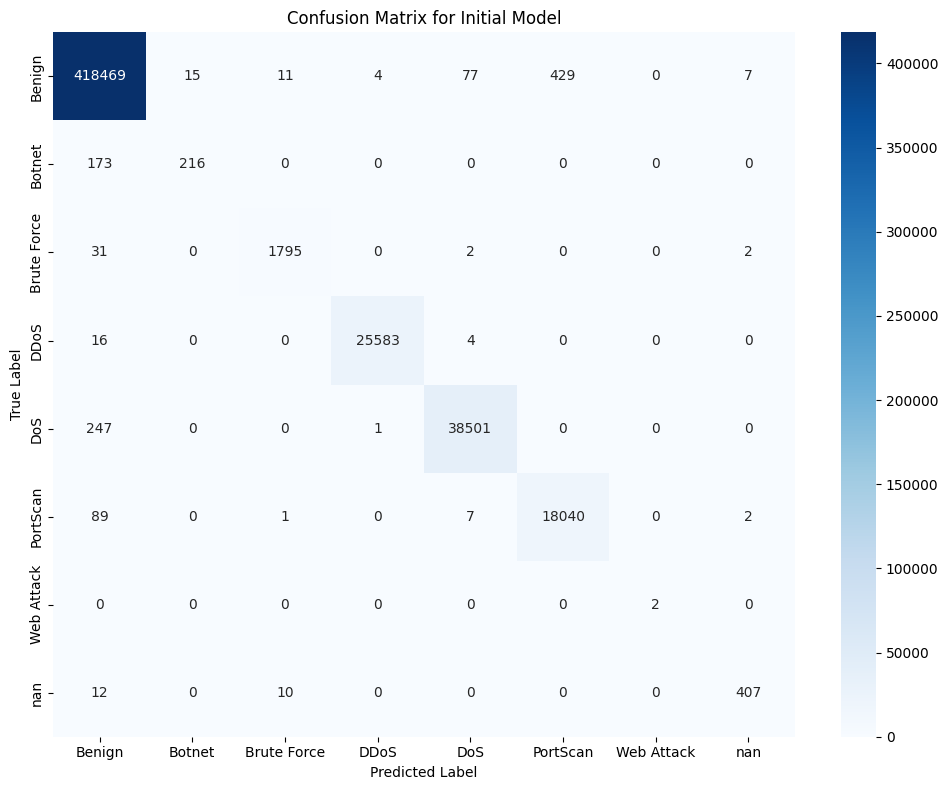

In [ ]:
# ==============================================================================
# 7. EVALUATE THE INITIAL XGBOOST MODEL
# ==============================================================================
print("Evaluating the initial XGBoost model on the test set...")

y_pred = xgb_model.predict(X_test_encoded)
accuracy = accuracy_score(y_test_np, y_pred)
print(f"\nAccuracy on the test set: {accuracy * 100:.2f}%")

# --- Check and prepare target names for report ---
if 'label_encoder' in locals() and hasattr(label_encoder, 'classes_'):
    target_names_str = [str(cls) for cls in label_encoder.classes_]
    print(f"\nUsing target names for report: {target_names_str}")
else:
    print("\nError: 'label_encoder' not found. Report will use numerical labels.")
    target_names_str = None

# --- Classification Report ---
try:
    report = classification_report(y_test_np, y_pred, target_names=target_names_str)
    print("\nClassification Report:")
    print(report)
except Exception as e:
    print(f"\nError generating classification report (falling back): {e}")
    report = classification_report(y_test_np, y_pred)
    print(report)

# --- Confusion Matrix ---
cm = confusion_matrix(y_test_np, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names_str, yticklabels=target_names_str)
plt.title('Confusion Matrix for Initial Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'initial_confusion_matrix.png'), dpi=300)
plt.show()

In [ ]:
# Insert this check right after the test set evaluation in Step 7

# Predict on the Training Set
X_train_encoded = encoder_model.predict(X_train_np) # Re-run prediction if not in memory
y_train_pred = xgb_model.predict(X_train_encoded)
train_accuracy = accuracy_score(y_train_np, y_train_pred)

print(f"\nTraining Set Accuracy: {train_accuracy * 100:.4f}%")
print(f"Test Set Accuracy (from evaluation): {accuracy * 100:.4f}%")
print(f"Difference: {(train_accuracy - accuracy) * 100:.4f}%")

63020/63020 ━━━━━━━━━━━━━━━━━━━━ 80s 1ms/step

Training Set Accuracy: 99.8157%
Test Set Accuracy (from evaluation): 99.7739%
Difference: 0.0419%


In [ ]:
# ==============================================================================
# 8. SIMULATE ARRIVAL OF NEW DATA FOR INCREMENTAL LEARNING
# ==============================================================================
print("Simulating the arrival of new data...")

new_data_fraction = 0.10
new_data_size = int(len(X_test_encoded) * new_data_fraction)

X_new = X_test_encoded[:new_data_size]
y_new = y_test_np[:new_data_size]

X_test_remaining = X_test_encoded[new_data_size:]
y_test_remaining = y_test_np[new_data_size:]

if len(X_test_remaining) == 0:
    print("\nWarning: Simulation used the entire test set. No remaining data for final evaluation.")

print(f"\nSimulated new data shapes (X_new, y_new): ({X_new.shape}, {y_new.shape})")
print(f"Remaining test data shapes: ({X_test_remaining.shape}, {y_test_remaining.shape})")

Simulating the arrival of new data...

Simulated new data shapes (X_new, y_new): ((50415, 32), (50415,))
Remaining test data shapes: ((453738, 32), (453738,))


In [ ]:
# ==============================================================================
# 9. INCREMENTAL XGBOOST TRAINING (FIXED - v3: Using Native Booster API)
# ==============================================================================
print("Performing incremental training on the XGBoost model...")

# --- Define the path to the model you just saved in Step 6 ---
initial_model_path = os.path.join(output_path, 'initial_xgb_model_tuned.json')

if not os.path.exists(initial_model_path):
    print(f"!!! ERROR: Initial model file '{initial_model_path}' not found. Run Step 6 first. !!!")
    exit()

# --- Check if y_train_np exists from Step 2/3 ---
if 'y_train_np' not in locals():
    print("!!! ERROR: 'y_train_np' (from Step 2/3) not found in memory.")
    print("Please re-run Step 2 and Step 3 to ensure 'y_train_np' is defined.")
    exit()

# --- Initialize a new XGBClassifier (parameters MUST match Step 6) ---
updated_xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=num_classes,  # num_classes was defined in Step 6
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    tree_method='hist',       # Using 'hist' (efficient CPU)
    n_estimators=200,         # We will use this to determine the number of new boosting rounds
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8
)

# Load the state of the initial model
print(f"Loading initial model from: {initial_model_path}")
updated_xgb_model.load_model(initial_model_path)
print("Initial XGBoost model loaded.")

# Get the existing booster object and parameters for native API training
booster = updated_xgb_model.get_booster()
params = updated_xgb_model.get_params()
params.pop('n_estimators', None) # Remove n_estimators as it's used as num_boost_round now

# ====================================================================
# --- FIX: FILTER NEW DATA BASED ON ORIGINAL TRAINING LABELS ---
# ====================================================================
# Get the classes the model was originally trained on (should be 0-7, which means 8 classes)
expected_classes = np.unique(y_train_np)
print(f"Model was originally trained on classes: {expected_classes}")

# Create a filter (mask) for y_new to only keep rows with these expected classes
mask = np.isin(y_new, expected_classes)
y_new_filtered = y_new[mask]
X_new_filtered = X_new[mask]

new_class_samples = len(y_new) - len(y_new_filtered)
if new_class_samples > 0:
    print(f"Ignoring {new_class_samples} samples belonging to classes not in the original training set.")

# --- Perform incremental training using Native API ---
print("Starting incremental fitting on filtered data...")

# Check if there's any data left to train on after filtering
if len(y_new_filtered) == 0:
    print("No new data matching the original model's classes. Skipping incremental update.")
else:
    # 1. Create a DMatrix for the new data
    dtrain_new = xgb.DMatrix(X_new_filtered, label=y_new_filtered)

    # 2. Perform the incremental training using the native train function
    # The xgb_model parameter is used to resume training from the existing booster.
    # We will add 100 new trees (rounds) for the update.
    num_rounds_to_add = 100 # Add 100 trees for the update

    # Use the filtered data for the incremental update
    updated_booster = xgb.train(
        params,
        dtrain_new,
        num_boost_round=num_rounds_to_add,
        xgb_model=booster # Key for incremental learning: continue from the loaded model
    )
    print(f"Incremental training complete. Added {num_rounds_to_add} new trees based on new data.")

    # 3. Update the scikit-learn wrapper with the new booster
    updated_xgb_model._Booster = updated_booster

    # --- Save the updated model ---
    updated_model_path = os.path.join(output_path, 'updated_xgb_model.json')
    updated_xgb_model.save_model(updated_model_path)
    print(f"Updated XGBoost model saved to: {updated_model_path}")

Performing incremental training on the XGBoost model...
Loading initial model from: /content/drive/MyDrive/Colab_Datasets/PreprocessedForproject/initial_xgb_model_tuned.json
Initial XGBoost model loaded.
Model was originally trained on classes: [0 1 2 3 4 5 6 7]
Starting incremental fitting on filtered data...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:50:44] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "enable_categorical", "missing", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Incremental training complete. Added 100 new trees based on new data.
Updated XGBoost model saved to: /content/drive/MyDrive/Colab_Datasets/PreprocessedForproject/updated_xgb_model.json



Evaluating the incrementally trained (updated) XGBoost model...

Accuracy of updated model on remaining test set: 99.73%

Classification Report (Updated Model):
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    377152
      Botnet       0.74      0.68      0.71       350
 Brute Force       0.99      0.98      0.98      1646
        DDoS       1.00      1.00      1.00     23063
         DoS       1.00      0.99      1.00     34762
    PortScan       0.97      0.99      0.98     16371
  Web Attack       1.00      1.00      1.00         2
         nan       0.97      0.92      0.94       392

    accuracy                           1.00    453738
   macro avg       0.96      0.95      0.95    453738
weighted avg       1.00      1.00      1.00    453738



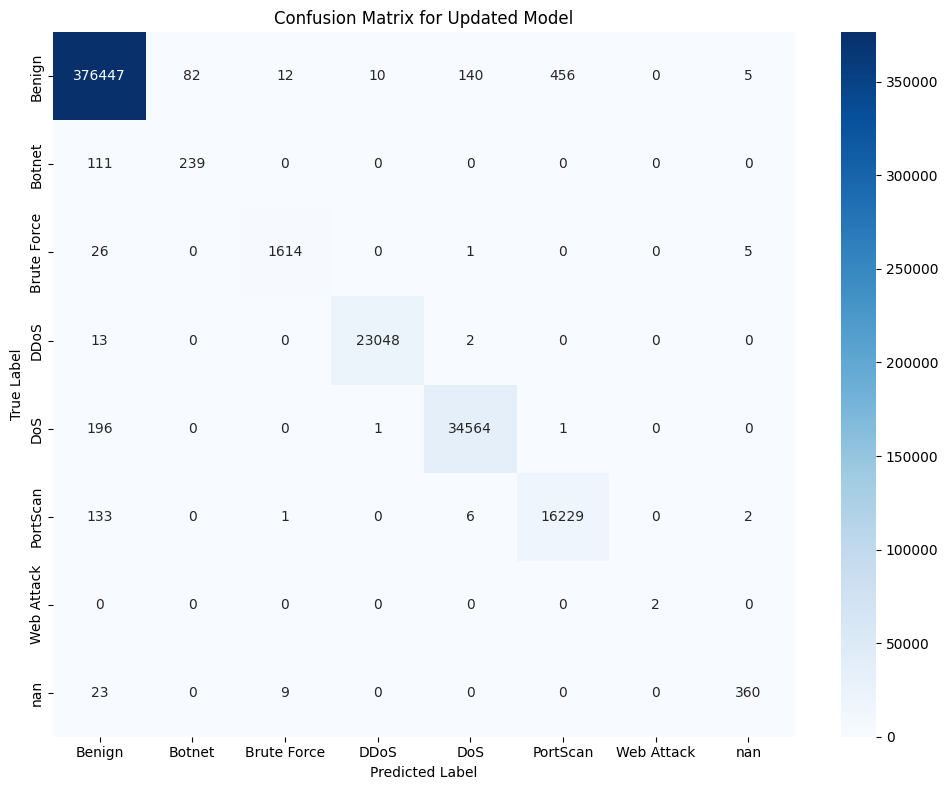


--- Model Implementation Complete ---


In [ ]:
# ==============================================================================
# 10. EVALUATE THE UPDATED XGBOOST MODEL
# ==============================================================================

# Check if there is any data left to test on
if 'X_test_remaining' not in locals() or len(X_test_remaining) == 0:
    print("Warning: 'X_test_remaining' is empty. No data left to evaluate the updated model.")
else:
    print("\nEvaluating the incrementally trained (updated) XGBoost model...")

    # Use the 'updated_xgb_model' (which is in memory from the last cell) to predict
    y_pred_updated = updated_xgb_model.predict(X_test_remaining)

    # --- Performance Metrics ---
    accuracy_updated = accuracy_score(y_test_remaining, y_pred_updated)
    print(f"\nAccuracy of updated model on remaining test set: {accuracy_updated * 100:.2f}%")

    # Use 'target_names_str' (created in Step 7) for the labels
    if 'target_names_str' not in locals():
        print("Warning: 'target_names_str' not found. Re-creating from 'label_encoder'.")
        target_names_str = [str(cls) for cls in label_encoder.classes_]

    report_updated = classification_report(y_test_remaining, y_pred_updated, target_names=target_names_str)
    print("\nClassification Report (Updated Model):")
    print(report_updated)

    # --- Confusion Matrix ---
    cm_updated = confusion_matrix(y_test_remaining, y_pred_updated)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_updated, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names_str, yticklabels=target_names_str)
    plt.title('Confusion Matrix for Updated Model')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    # Save the plot
    plt.savefig(os.path.join(output_path, 'updated_confusion_matrix.png'), dpi=300)
    plt.show()

print("\n--- Model Implementation Complete ---")